# Prediction of Obesity Risk Based On Lifestyle Factors

## Model Building, Prediction and Evaluation

### Objectives
* Feature Engineering: Load `cleaned_obesity.csv`, compute the BMI feature from individual height and weight measurements, and apply encoding schemes (`LabelEncoder` for the 7-class target; `get_dummies` for predictor variables).
* Baseline Model Establishment: Fit a full-model Multinomial Logistic Regression prior to dataset splitting to establish a benchmark performance metric.
* Feature Selection: Apply F-Score testing and Random Forest feature importance methods to identify the most impactful lifestyle predictors and optimise model efficiency.
* Model Fitting & Fine-Tuning: Train and optimize four classification architectures: Multinomial Logistic Regression, Decision Trees, K-Nearest Neighbors (KNN) and Neural Networks, using `RandomizedSearchCV` across defined parameter grids.
* Model Evaluation & Performance Metrics: Evaluate test set performance using multi-class accuracy, precision, recall, and F1-score metrics.
* Statistical Significance Validation: Perform paired sample t-tests across model cross-validation results to establish p-values and verify whether performance gains between algorithms are statistically significant.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import io
import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Feature Engineering

In [6]:
#Reading the dataset
obesity = pd.read_csv("obesity_cleaned.csv")

#Creating the BMI variable
obesity['bmi'] = obesity['weight']/(obesity['height']**2)

#Dropping the two variables
column_drop = ['weight', 'height']
obesity = obesity.drop(column_drop, axis = 1)

#### Encoding the Target Feature

The response variable `obs` of the dataset will be renamed to `target`, while the rest of the features will be called as `predictors`.

In [9]:
predictors = obesity.drop(columns = 'obs')
target = obesity['obs']

#Identifying the levels in the target feature
target.value_counts()

obs
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

The target feature has 7 levels. Using `LabelEncoder`, the target feature will be encoded such that 7 string levels will be coverted into integer class labels.

In [11]:
#Encoding the target feature
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
target = le.fit_transform(target)

#Mapping the unique levels of the target feature
label_map = pd.DataFrame({
    'Original': le.classes_,
    'Encoded': range(len(le.classes_))
})
print(label_map)

              Original  Encoded
0  Insufficient_Weight        0
1        Normal_Weight        1
2       Obesity_Type_I        2
3      Obesity_Type_II        3
4     Obesity_Type_III        4
5   Overweight_Level_I        5
6  Overweight_Level_II        6


#### Encoding the Predictor Variables

Now that the target column has been encoded, similar procedures will be performed for the predictor variables. The binary variables will be coded into a single column such that 'Yes' and 'No' will be encoded to 'True' and 'False' respectively. While categorical variables with more than two levels, *q-1* dummy variables will be created to represent the *q* levels of variables. Introducing *q* dummy variables will lead to the dummy variable trap and thereby hinder the performance of the models.

In [14]:
#Identifying categorical variables in the dataset
categorical_cols = obesity.columns[obesity.dtypes == object].tolist()
categorical_cols

#Removing obs from categorical_cols 
categorical_cols.remove('obs')

#Encoding for categorical features with two levels only
for col in categorical_cols:
    if (predictors[col].nunique() == 2):
        predictors[col] = pd.get_dummies(predictors[col], drop_first = True)

#Encoding for categorical features with more than two levels
predictors = pd.get_dummies(predictors, drop_first = True)

#Checking the columns after performing one-hot-encoding
predictors.columns

Index(['gender', 'age', 'famhis', 'calorie', 'veg', 'meal', 'smoke', 'ch2o',
       'calom', 'exc', 'tech', 'bmi', 'btw_Frequently', 'btw_Sometimes',
       'btw_no', 'alco_Frequently', 'alco_Sometimes', 'alco_no', 'mtrans_Bike',
       'mtrans_Motorbike', 'mtrans_Public_Transportation', 'mtrans_Walking'],
      dtype='object')

### Baseline Model Establishment

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold

The performance of the model will be assessed using all the features in the dataset. Using `LogisticRegression`, we perform multinomial logistic regression on the dataset. The evaluation will involve a stratified 5-fold cross-validation procedure, repeated 5 times. For assessing the model performance, the accuracy score will be employed. 

In [18]:
mlr = LogisticRegression(multi_class = 'multinomial', random_state = 999)

cv_method = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 5, random_state = 999)

cv_results = cross_val_score(estimator = mlr,
                             X = predictors,
                             y = target, 
                             cv = cv_method, 
                             scoring = 'accuracy')

cv_results

array([0.72813239, 0.66587678, 0.71090047, 0.71563981, 0.72037915,
       0.72340426, 0.69194313, 0.72274882, 0.72985782, 0.71090047,
       0.69503546, 0.6943128 , 0.71090047, 0.73933649, 0.73222749,
       0.71631206, 0.73933649, 0.7014218 , 0.71563981, 0.72748815,
       0.72813239, 0.68483412, 0.75118483, 0.7014218 , 0.71090047])

The `cv_results` array produces 25 values as a result of the 5 repetition/ 5 fold combination. The average of the 25 accuracy scores is calculated to evaluate the model prior to feature selection.

In [20]:
cv_results.mean().round(3)

0.715

The average accuracy score is 0.715, i.e., the model correctly predicted the target class for approximately 71.5% of the samples in the dataset it was evaluated on. The accuracy score of 0.715 indicates room for significant improvement, which can be achieved through feature selection.

### Feature Selection

The primary goal of feature selection is to eliminate irrelevant or noisy features that can confuse a model and degrade its predictive power. By focusing the model on only the most pertinent information, it can discern true patterns more effectively, leading to sharper insights and higher accuracy.

The feature selection will be performed using the F-score. Based on the ANOVA F-test, the F-score within `sklearn.feature_selection.f_classif` evaluates whether a feature's average values are distinct enough among the different target groups to be considered predictive.

The code below returns the indices of 7 features that have the highest F-Score value sorted from the highest to the lowest. 

In [24]:
from sklearn import feature_selection as fs

num_features = 7
fs_fit_fscore = fs.SelectKBest(fs.f_classif, k = num_features)
fs_fit_fscore.fit_transform(predictors, target)
fs_indices_fscore = np.argsort(np.nan_to_num(fs_fit_fscore.scores_))[::-1][0:num_features]

feature_fscore = fs_fit_fscore.scores_[fs_indices_fscore]

best = predictors.columns[fs_indices_fscore].values
best

array(['bmi', 'gender', 'famhis', 'btw_Sometimes', 'veg',
       'btw_Frequently', 'age'], dtype=object)

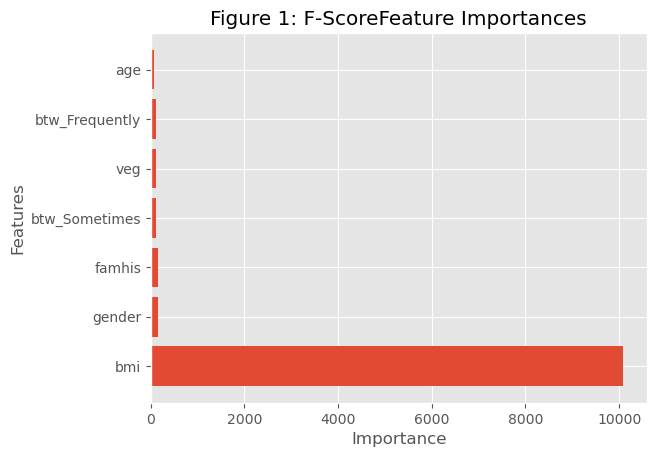

In [25]:
plt.style.use("ggplot")

#Defining a function to create the plots
def plot_imp(best, scores, method_name):   
    plt.barh(best, scores)
    plt.title(method_name + 'Feature Importances')
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()

#Plotting the F-scores
plot_imp(best, feature_fscore, 'Figure 1: F-Score')

Based on Figure 1, the F-scores strongly indicate that BMI (Body Mass Index) is the most significant feature in predicting obesity risk level. Additionally, other prominent features identified as important include gender, family history of obesity, food intake between meals, vegetable consumption, and age.

To further validate these findings and cross-verify the true significance of these features, a `RandomForestClassifier` will be implemented. This ensemble model is well-suited for determining feature importance, and its application will serve as a robust method to independently assess and confirm the hierarchy of influential factors contributing to obesity risk prediction.

In [27]:
from sklearn.ensemble import RandomForestClassifier

model_rfi = RandomForestClassifier(n_estimators = 100)
model_rfi.fit(predictors, target)
fs_indices_rfi = np.argsort(model_rfi.feature_importances_)[::-1][0:num_features]

feature_importances_rfi = model_rfi.feature_importances_[fs_indices_rfi]

best_features_rfi = predictors.columns[fs_indices_rfi].values
best_features_rfi

array(['bmi', 'age', 'veg', 'meal', 'gender', 'tech', 'exc'], dtype=object)

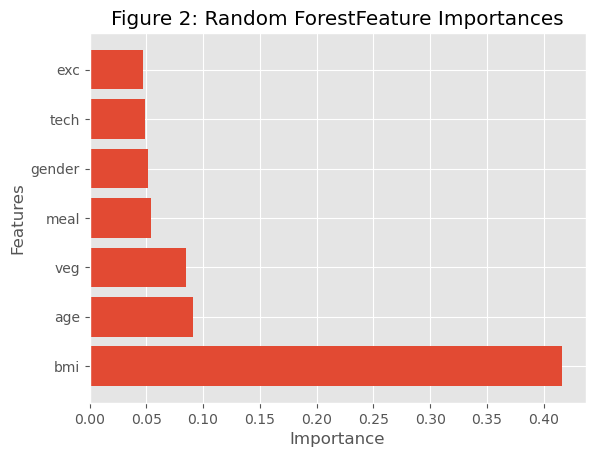

In [28]:
plot_imp(best_features_rfi, feature_importances_rfi, 'Figure 2: Random Forest')

From Figure 2, `bmi` is glaringly the important feature for the model, followed by age, vegetable consumption, meal intake, gender, water consumption and number of hours of excercise.

From the above two feature selection methods, the F-score being a filter mthods assess the linear relationship between the variables while the Random Forest Classifier being tree-based, measures how much each feature contributes to reducing impurity or noise in the model. Together, the F-score identifies univariate importance, while Random Forest provides multivariate importance. When both methods agree on the importance of certain features, it strengthens the relevance of the variables.

On comparison, `bmi`, `age`, `gender` and `veg` appear to be important in both method, thus these variables should be included in the model. Based on domain knowledge, `famhis`, `exc`, `meal` and `tech` are known to have significant impact on the risk of obesity. This statement can be strengthend by the descriptive statistics performed in Phase 1, where notable relationship was found between `famhis` and risk of obesity. Moreover, many studies show that people tend to eat more and make less healthy food choices while watching TV or using other screens, often consuming energy-dense snacks and sugary drinks (Robinson, 2017). Consequently, this leads to reduced physical activity. 

Hence, a model based on the these 8 important variables will be created. This model will be compared with the baseline model which includes all variables. If the accuracy score of the reduced model is equal to or greater than the full model, the reduced model will be employed for model fitting and tuning.

In [30]:
#Creating the reduced model
obesity_red = predictors[['bmi', 'age', 'gender', 'veg', 'famhis', 'exc', 'meal', 'tech']]

#Observing the first 5 observations
obesity_red.head(5)

,bmi,age,gender,veg,famhis,exc,meal,tech
0,24.386526,21.0,False,2.0,True,0.0,3.0,1.0
1,24.238227,21.0,False,3.0,True,3.0,3.0,0.0
2,23.765432,23.0,True,2.0,True,2.0,3.0,1.0
3,26.851852,27.0,True,3.0,False,2.0,3.0,0.0
4,28.342381,22.0,True,2.0,False,0.0,1.0,0.0


In [31]:
# Running MLR on the reduced model
cv_results = cross_val_score(estimator = mlr,
                             X = obesity_red,
                             y = target, 
                             cv = cv_method, 
                             scoring = 'accuracy')

cv_results.mean().round(3)

0.593

The comparative evaluation highlighted a substantial performance gap. The full model achieved a robust cross-validated accuracy of 0.71, outperforming the reduced model's 0.592, which was based on eight selected features ('bmi', 'age', 'gender', 'veg', 'famhis', 'exc', 'meal', 'tech'). This outcome suggests that the features deemed less significant in the initial selection process, when combined, contribute meaningfully to the model's predictive strength, making their retention in the full model advantageous.

Prioritising predictive performance, the full model will be selected for subsequent model fitting and hyperparameter tuning.

### Model Fitting & Fine-tuning

Using `train_test_split`, the dataset will be divided into training and testing sets by a ratio of 70:30, i.e., 70 percent of the data will be used to build the model and 30 percent of the data will be used to evaluate the performance of the model.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Spliting the dataset into test and training data
X_train, X_test, y_train, y_test = train_test_split(predictors, target, test_size = 0.3, stratify = target, random_state = 999)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Target classes in training:\n{np.unique(y_train, return_counts = True)}")
print(f"Target classes in testing:\n{np.unique(y_test, return_counts = True)}")

Training set shape: (1477, 22)
Testing set shape: (634, 22)
Target classes in training:
(array([0, 1, 2, 3, 4, 5, 6]), array([190, 201, 245, 208, 227, 203, 203]))
Target classes in testing:
(array([0, 1, 2, 3, 4, 5, 6]), array([ 82,  86, 106,  89,  97,  87,  87]))


#### Hyperparameter Tuning

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Defining the numerical features
numerical_features = ['bmi', 'age', 'veg', 'meal', 'ch2o', 'exc', 'tech']

#Creating a preprocessing Pipeline for scaling numerical features
preprocessor = ColumnTransformer(transformers = [('num', StandardScaler(), numerical_features)], remainder = 'passthrough')

In [38]:
from sklearn.model_selection import StratifiedKFold

#Defining the cross-validation strategy and scoring metric
cv_strategy = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 999)
scoring_metric = 'accuracy'

print(f"\nOptimisation Metric: {scoring_metric}")
print(f"Cross-Validation Strategy: {cv_strategy.n_splits}-fold StratifiedKFold")


Optimisation Metric: accuracy
Cross-Validation Strategy: 5-fold StratifiedKFold


#### Mutinomial Logistic Regression

In [40]:
#Defining the parameter space
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(solver = 'saga', random_state = 999, max_iter = 15000))
])

multinomial_lr_param_grid = {
    'logreg__C': np.logspace(-4, 2, 7),
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [10000, 20000, 30000]
}

In [41]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#Number of parameter settings to sample for RandomizedSearchCV
n_iter_search = 50 

#Performing the tuning
random_search_lr = RandomizedSearchCV(
    estimator = lr_pipeline,
    param_distributions = multinomial_lr_param_grid,
    n_iter = n_iter_search, 
    scoring = scoring_metric,
    cv = cv_strategy,
    n_jobs = -1,
    verbose = 1,
    random_state = 999
)
random_search_lr.fit(X_train, y_train)

print("\n--- Multinomial Logistic Regression RandomizedSearchCV Results ---")
print(f"Best parameters: {random_search_lr.best_params_}")
print(f"Best cross-validation {scoring_metric}: {random_search_lr.best_score_:.4f}")
best_lr_rand = random_search_lr.best_estimator_

Fitting 5 folds for each of 42 candidates, totalling 210 fits

--- Multinomial Logistic Regression RandomizedSearchCV Results ---
Best parameters: {'logreg__penalty': 'l1', 'logreg__max_iter': 10000, 'logreg__C': 1.0}
Best cross-validation accuracy: 0.9614


#### Decision Trees

In [43]:
from sklearn.tree import DecisionTreeClassifier

#Defining the parameter space
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=42))
])

decision_tree_param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [None, 5, 10, 15, 20, 25, 30],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 4, 8],
    'dt__max_features': ['sqrt', 'log2', None]
}

In [44]:
#Performing the tuning
random_search_dt = RandomizedSearchCV(
    estimator = dt_pipeline,
    param_distributions = decision_tree_param_grid,
    n_iter = n_iter_search,
    scoring = scoring_metric,
    cv = cv_strategy,
    n_jobs = -1,
    verbose = 1,
    random_state = 999
)
random_search_dt.fit(X_train, y_train)

print("\n--- Decision Tree RandomizedSearchCV Results ---")
print(f"Best parameters: {random_search_dt.best_params_}")
print(f"Best cross-validation {scoring_metric}: {random_search_dt.best_score_:.4f}")
best_dt_rand = random_search_dt.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Decision Tree RandomizedSearchCV Results ---
Best parameters: {'dt__min_samples_split': 20, 'dt__min_samples_leaf': 2, 'dt__max_features': None, 'dt__max_depth': 10, 'dt__criterion': 'gini'}
Best cross-validation accuracy: 0.9689


#### K-Nearest Neighbors

In [46]:
from sklearn.neighbors import KNeighborsClassifier

#Defining the parameter space
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': list(range(1, 25, 2)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

In [47]:
#Performing the tuning
random_search_knn = RandomizedSearchCV(
    estimator = knn_pipeline,
    param_distributions = knn_param_grid,
    n_iter = n_iter_search,
    scoring = scoring_metric,
    cv = cv_strategy,
    n_jobs = -1,
    verbose = 1,
    random_state = 999
)
random_search_knn.fit(X_train, y_train)

print("\n--- KNN RandomizedSearchCV Results ---")
print(f"Best parameters: {random_search_knn.best_params_}")
print(f"Best cross-validation {scoring_metric}: {random_search_knn.best_score_:.4f}")
best_knn_rand = random_search_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- KNN RandomizedSearchCV Results ---
Best parameters: {'knn__weights': 'uniform', 'knn__n_neighbors': 1, 'knn__metric': 'manhattan'}
Best cross-validation accuracy: 0.8646


#### Neural Networks

In [49]:
from sklearn.neural_network import MLPClassifier

#Defining the parameter space
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('mlp', MLPClassifier(max_iter = 1000, random_state = 999))
])

mlp_param_grid = {'mlp__hidden_layer_sizes':[
        (16,),        #one hidden layer with 16 neurons
        (32,),        #one hidden layer with 32 neurons
        (64,),        #one hidden layer with 64 neurons
        (32, 16),     #two hidden layers: 32 in first, 16 in second
        (64, 32),     #two hidden layers: 64 in first, 32 in second
        (64, 64),     #two hidden layers: 64 in each (to test if constant size works better)
        (64, 32, 16)], #three hidden layers: 64 in first, 32 in second, 16 in third
    'mlp__batch_size': [64, 128],
    'mlp__max_iter': [1500, 2000],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam', 'sgd'],
    'mlp__alpha': [0.0001, 0.001, 0.01, 0.1],
    'mlp__learning_rate_init': [0.001, 0.01, 0.05, 0.1],
    'mlp__learning_rate': ['constant', 'adaptive']
}

#Setting the metric
scoring_metric = 'accuracy'

#Performing the tuning
random_search_mlp = RandomizedSearchCV(
    estimator = mlp_pipeline,
    param_distributions = mlp_param_grid,
    n_iter = 50, 
    scoring = scoring_metric,
    cv = cv_strategy,
    n_jobs = -1,
    verbose = 0,
    random_state = 999
)
random_search_mlp.fit(X_train, y_train)

print("\n--- Neural Network RandomizedSearchCV Results ---")
print(f"\nBest parameters for MLP: {random_search_mlp.best_params_}")
print(f"Best cross-validation score for MLP: {random_search_mlp.best_score_:.4f}")
best_mlp_rand = random_search_mlp.best_estimator_


--- Neural Network RandomizedSearchCV Results ---

Best parameters for MLP: {'mlp__solver': 'sgd', 'mlp__max_iter': 1500, 'mlp__learning_rate_init': 0.05, 'mlp__learning_rate': 'constant', 'mlp__hidden_layer_sizes': (64, 32), 'mlp__batch_size': 64, 'mlp__alpha': 0.001, 'mlp__activation': 'tanh'}
Best cross-validation score for MLP: 0.9628


### Model Evaluation & Performance Metrics

In [51]:
#Importing the neccessary modules
from sklearn.metrics import classification_report, confusion_matrix

Based on the training data, the following are the accuracy scores for the models:
- Multinomial Logistic Regression: 0.9614
- Decision Trees: 0.9689
- K-Nearest Neighbors: 0.8646
- Neural Network: 0.9648

Following, accuracy, recall, precision and f1-score will be derived by testing the model on the test data.

#### Multinomial Logistic Regression

In [54]:
#Testing the model
y_pred_lr = best_lr_rand.predict(X_test)

#Classification report
print(f"Metrics of Multinomial Logistic Regression Model")
print(classification_report(y_test, y_pred_lr, digits = 4, target_names = le.classes_))

Metrics of Multinomial Logistic Regression Model
                     precision    recall  f1-score   support

Insufficient_Weight     0.9647    1.0000    0.9820        82
      Normal_Weight     0.9873    0.9070    0.9455        86
     Obesity_Type_I     1.0000    0.9717    0.9856       106
    Obesity_Type_II     0.9670    0.9888    0.9778        89
   Obesity_Type_III     0.9898    1.0000    0.9949        97
 Overweight_Level_I     0.8763    0.9770    0.9239        87
Overweight_Level_II     0.9877    0.9195    0.9524        87

           accuracy                         0.9669       634
          macro avg     0.9675    0.9663    0.9660       634
       weighted avg     0.9689    0.9669    0.9670       634



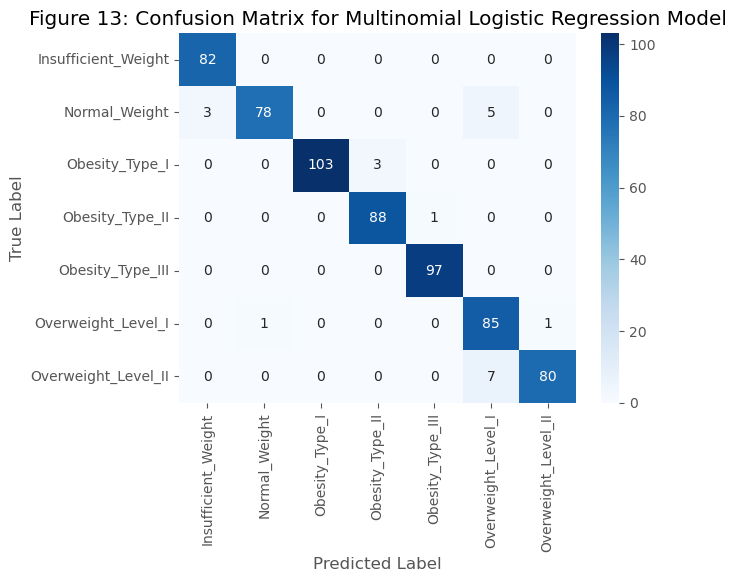

In [55]:
#Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot = True, cmap = 'Blues', fmt = 'd', xticklabels = le.classes_, yticklabels = le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 13: Confusion Matrix for Multinomial Logistic Regression Model')
plt.show()

#### Decision Trees

In [57]:
#Testing the model
y_pred_dt = best_dt_rand.predict(X_test)

#Classification report
print(f"Metrics of Decision Trees Model")
print(classification_report(y_test, y_pred_dt, digits = 4, target_names = le.classes_))

Metrics of Decision Trees Model
                     precision    recall  f1-score   support

Insufficient_Weight     1.0000    1.0000    1.0000        82
      Normal_Weight     0.9884    0.9884    0.9884        86
     Obesity_Type_I     0.9901    0.9434    0.9662       106
    Obesity_Type_II     0.9565    0.9888    0.9724        89
   Obesity_Type_III     0.9898    1.0000    0.9949        97
 Overweight_Level_I     0.9556    0.9885    0.9718        87
Overweight_Level_II     0.9882    0.9655    0.9767        87

           accuracy                         0.9811       634
          macro avg     0.9812    0.9821    0.9815       634
       weighted avg     0.9814    0.9811    0.9810       634



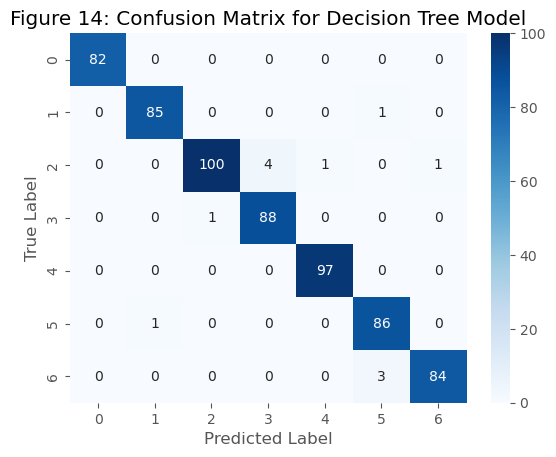

In [58]:
#Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot = True, cmap = 'Blues', fmt = 'd')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 14: Confusion Matrix for Decision Tree Model')
plt.show()

#### K-Nearest Neighbors

In [60]:
#Testing the model
y_pred_knn = best_knn_rand.predict(X_test)

#Classification report
print(f"Metrics of KNN Model")
print(classification_report(y_test, y_pred_knn, digits = 4, target_names = le.classes_))

Metrics of KNN Model
                     precision    recall  f1-score   support

Insufficient_Weight     0.8795    0.8902    0.8848        82
      Normal_Weight     0.7294    0.7209    0.7251        86
     Obesity_Type_I     0.9439    0.9528    0.9484       106
    Obesity_Type_II     0.9780    1.0000    0.9889        89
   Obesity_Type_III     1.0000    1.0000    1.0000        97
 Overweight_Level_I     0.8675    0.8276    0.8471        87
Overweight_Level_II     0.9091    0.9195    0.9143        87

           accuracy                         0.9054       634
          macro avg     0.9011    0.9016    0.9012       634
       weighted avg     0.9046    0.9054    0.9049       634



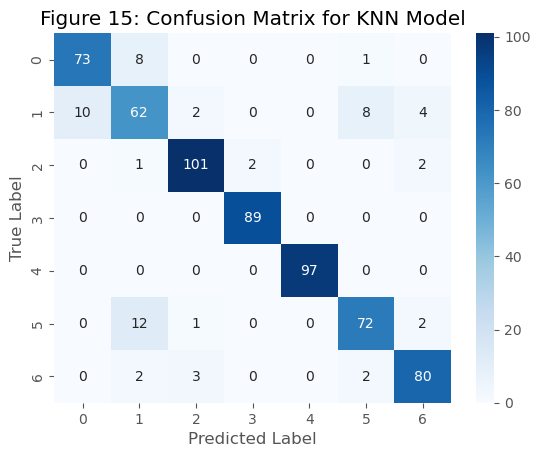

In [61]:
#Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot = True, cmap = 'Blues', fmt = 'd')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 15: Confusion Matrix for KNN Model')
plt.show()

#### Neural Network

In [63]:
#Testing the model
y_pred_mlp = best_mlp_rand.predict(X_test)

#Classification report
print(f"Metrics of Neural Network Model")
print(classification_report(y_test, y_pred_mlp, digits = 4, target_names = le.classes_))

Metrics of Neural Network Model
                     precision    recall  f1-score   support

Insufficient_Weight     0.9310    0.9878    0.9586        82
      Normal_Weight     0.9494    0.8721    0.9091        86
     Obesity_Type_I     0.9905    0.9811    0.9858       106
    Obesity_Type_II     0.9775    0.9775    0.9775        89
   Obesity_Type_III     0.9898    1.0000    0.9949        97
 Overweight_Level_I     0.9032    0.9655    0.9333        87
Overweight_Level_II     1.0000    0.9540    0.9765        87

           accuracy                         0.9637       634
          macro avg     0.9631    0.9626    0.9622       634
       weighted avg     0.9646    0.9637    0.9636       634



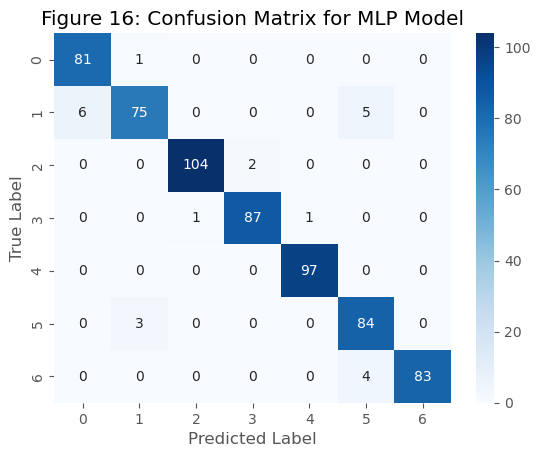

In [64]:
#Confusion matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm_mlp, annot = True, cmap = 'Blues', fmt = 'd')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 16: Confusion Matrix for MLP Model')
plt.show()

### Statistical Significance Validation

In [66]:
cv_method_ttest = RepeatedStratifiedKFold(n_splits = 5, 
                                          n_repeats = 5, 
                                          random_state = 111)

cv_results_lr = cross_val_score(estimator = best_lr_rand,
                                 X = predictors,
                                 y = target, 
                                 cv = cv_method_ttest, 
                                 n_jobs = -2,
                                 scoring = 'accuracy')

cv_results_dt = cross_val_score(estimator = best_dt_rand,
                                 X = predictors,
                                 y = target, 
                                 cv = cv_method_ttest, 
                                 n_jobs = -2,
                                 scoring = 'accuracy')

cv_results_knn = cross_val_score(estimator = best_knn_rand,
                                 X = predictors,
                                 y = target, 
                                 cv = cv_method_ttest, 
                                 n_jobs = -2,
                                 scoring = 'accuracy')

cv_results_mlp = cross_val_score(estimator = best_mlp_rand,
                                 X = predictors,
                                 y = target, 
                                 cv = cv_method_ttest, 
                                 n_jobs = -2,
                                 scoring = 'accuracy')

In [67]:
#Importing the neccessary module
from scipy import stats

#mlr vs dt
print(f"p-value of Multinomial Logistic Regression and Decision Tree using paired t-test")
print(stats.ttest_rel(cv_results_lr, cv_results_dt).pvalue.round(3))
print(""*80)

#mlr vs knn
print(f"p-value of Multinomial Logistic Regression and K-Nearest Neighbor using paired t-test")
print(stats.ttest_rel(cv_results_lr, cv_results_knn).pvalue.round(100))
print(""*80)

#mlr vs mlp
print(f"p-value of Multinomial Logistic Regression and Neural Network using paired t-test")
print(stats.ttest_rel(cv_results_lr, cv_results_mlp).pvalue.round(7))
print(""*80)

#dt vs knn
print(f"p-value of Decision Tree and K-Nearest Neighbor using paired t-test")
print(stats.ttest_rel(cv_results_dt, cv_results_knn).pvalue.round(100))
print(""*80)

#dt vs mlp
print(f"p-value of Decision Tree and Neural Network using paired t-test")
print(stats.ttest_rel(cv_results_dt, cv_results_mlp).pvalue.round(7))
print(""*80)

#knn vs mlp
print(f"p-value of K-Nearest Neighbor and Neural Network using paired t-test")
print(stats.ttest_rel(cv_results_knn, cv_results_mlp).pvalue.round(100))
print(""*80)

p-value of Multinomial Logistic Regression and Decision Tree using paired t-test
0.561

p-value of Multinomial Logistic Regression and K-Nearest Neighbor using paired t-test
2.586188020403957e-16

p-value of Multinomial Logistic Regression and Neural Network using paired t-test
0.0432443

p-value of Decision Tree and K-Nearest Neighbor using paired t-test
1.876675988806375e-18

p-value of Decision Tree and Neural Network using paired t-test
0.2039085

p-value of K-Nearest Neighbor and Neural Network using paired t-test
1.4553771981862977e-17



Multinomial Logistic Regression vs. Decision Tree (p = 0.561): No significant difference.
<br>Multinomial Logistic Regression vs. K-Nearest Neighbor (p = 2.586e-16): Highly significant difference.
<br>Multinomial Logistic Regression vs. Neural Network (p = 0.0008376): Significant difference.
<br>Decision Tree vs. K-Nearest Neighbor (p = 1.876e-18): Highly significant difference.
<br>Decision Tree vs. Neural Network (p = 0.0127373): Significant difference.
<br>K-Nearest Neighbor vs. Neural Network (p = 1.674e-17): Highly significant difference.

In summary, Multinomial Logistic Regression and Decision Tree perform similarly. However, all other model pairs show statistically significant differences in performance, suggesting that K-Nearest Neighbor and Neural Network, in particular, differ considerably from each other and the other models.